In [1]:
# Cell 1: Imports and Setup
!pip install minigrid gymnasium torch torchvision

import gymnasium as gym
import minigrid
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from collections import deque, defaultdict
from minigrid.wrappers import ImgObsWrapper
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
# Cell 2: Environment Setup
env = gym.make("MiniGrid-DoorKey-8x8-v0")

# Convert observation to image only (7x7x3 tensor)
env = ImgObsWrapper(env)

obs, _ = env.reset()

print("Observation shape:", obs.shape)
print("Number of actions:", env.action_space.n)
print("Max steps per episode:", env.unwrapped.max_steps)

Observation shape: (7, 7, 3)
Number of actions: 7
Max steps per episode: 640


In [3]:
# Cell 3: Improved DRQN Network (Smaller, More Efficient)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DRQN(nn.Module):
    def __init__(self, n_actions, hidden_size=64):
        super(DRQN, self).__init__()
        
        # Reduced network size for simpler environment
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1),  # Reduced from 32
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1),  # Reduced from 64
            nn.ReLU()
        )
        
        # 7x7 -> 5x5 -> 3x3
        self.feature_size = 32 * 3 * 3  # 288 features
        
        self.lstm = nn.LSTM(self.feature_size, hidden_size, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, n_actions)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len, H, W, C)
        B, T, H, W, C = x.shape
        
        # Reshape for conv layers
        x = x.reshape(B * T, H, W, C)
        x = x.float() / 10
        x = x.permute(0, 3, 1, 2)  # NCHW
        
        # Conv layers
        x = self.conv(x)
        x = x.reshape(B, T, -1)
        
        # LSTM
        lstm_out, hidden = self.lstm(x, hidden)
        
        # Q-values
        q_values = self.fc(lstm_out)
        
        return q_values, hidden


n_actions = env.action_space.n

policy_net = DRQN(n_actions, hidden_size=64).to(device)
target_net = DRQN(n_actions, hidden_size=64).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

# Count parameters
total_params = sum(p.numel() for p in policy_net.parameters())
print(f"Total parameters: {total_params:,}")

Using device: cuda
Total parameters: 96,167


In [4]:
# Cell 4: Fixed Replay Buffer (Handles Short Episodes Properly)
class ReplayBuffer:
    def __init__(self, capacity, seq_len):
        self.buffer = deque(maxlen=capacity)
        self.seq_len = seq_len

    def push(self, episode):
        """Store a complete episode"""
        self.buffer.append(episode)

    def sample(self, batch_size):
        """Sample sequences, handling short episodes properly"""
        if len(self.buffer) < batch_size:
            return None
        
        batch_states = []
        batch_actions = []
        batch_rewards = []
        batch_next_states = []
        batch_dones = []
        
        sampled_count = 0
        max_attempts = batch_size * 3  # Prevent infinite loops
        attempts = 0
        
        while sampled_count < batch_size and attempts < max_attempts:
            attempts += 1
            ep = random.choice(self.buffer)
            
            # Skip episodes that are too short
            if len(ep) < self.seq_len:
                continue
            
            # Sample a random sequence from this episode
            start = random.randint(0, len(ep) - self.seq_len)
            sequence = ep[start:start+self.seq_len]
            
            states, actions, rewards, next_states, dones = zip(*sequence)
            
            batch_states.append(states)
            batch_actions.append(actions)
            batch_rewards.append(rewards)
            batch_next_states.append(next_states)
            batch_dones.append(dones)
            
            sampled_count += 1
        
        # If we couldn't get enough samples, return None
        if sampled_count < batch_size:
            return None
        
        return (
            torch.tensor(np.array(batch_states), dtype=torch.float32).to(device),
            torch.tensor(batch_actions, dtype=torch.int64).to(device),
            torch.tensor(batch_rewards, dtype=torch.float32).to(device),
            torch.tensor(np.array(batch_next_states), dtype=torch.float32).to(device),
            torch.tensor(batch_dones, dtype=torch.float32).to(device)
        )

    def __len__(self):
        return len(self.buffer)


seq_len = 16
buffer = ReplayBuffer(capacity=10000, seq_len=seq_len)  # Increased capacity

print(f"Replay buffer created with capacity 10000 and sequence length {seq_len}")

Replay buffer created with capacity 10000 and sequence length 16


In [5]:
# Cell 5 UPDATED: Hyperparameters with SLOWER Epsilon Decay

gamma = 0.99
lr = 1e-4

batch_size = 32
target_update_freq = 500

epsilon_start = 1.0
epsilon_final = 0.05  # Increased from 0.01 - keep some exploration
epsilon_decay = 30000  # INCREASED from 5000 - decay 6x slower!

optimizer = optim.Adam(policy_net.parameters(), lr=lr)

# Tracking variables
steps_done = 0
update_count = 0

# For count-based exploration bonus
state_visit_counts = defaultdict(int)

print("Hyperparameters (UPDATED):")
print(f"  Learning rate: {lr}")
print(f"  Gamma: {gamma}")
print(f"  Batch size: {batch_size}")
print(f"  Epsilon decay: {epsilon_decay} (SLOWER - was 5000)")
print(f"  Epsilon final: {epsilon_final} (HIGHER - was 0.01)")
print(f"  Target update frequency: {target_update_freq}")
print()
print("Key change: Epsilon will stay above 0.1 until ~episode 1500")
print("This gives the agent more time to learn before exploiting")

Hyperparameters (UPDATED):
  Learning rate: 0.0001
  Gamma: 0.99
  Batch size: 32
  Epsilon decay: 30000 (SLOWER - was 5000)
  Epsilon final: 0.05 (HIGHER - was 0.01)
  Target update frequency: 500

Key change: Epsilon will stay above 0.1 until ~episode 1500
This gives the agent more time to learn before exploiting


In [6]:
# Cell 6: Improved Training Functions
def get_exploration_bonus(state, beta=0.01):
    """Count-based exploration bonus"""
    state_key = state.tobytes()
    count = state_visit_counts[state_key]
    state_visit_counts[state_key] = count + 1
    
    # Exploration bonus decreases as state is visited more
    return beta / np.sqrt(count + 1)


def select_action(state, hidden, epsilon):
    """Select action using epsilon-greedy with current hidden state"""
    global steps_done
    steps_done += 1
    
    if random.random() < epsilon:
        return env.action_space.sample(), hidden
    else:
        with torch.no_grad():
            state_tensor = torch.tensor(state).unsqueeze(0).unsqueeze(0).to(device)
            q_values, hidden = policy_net(state_tensor, hidden)
            action = q_values[:, -1].argmax(dim=1).item()
            return action, hidden


def train_step():
    """Single training step with proper DRQN training"""
    global update_count
    
    if len(buffer) < batch_size:
        return None
    
    # Sample batch
    batch = buffer.sample(batch_size)
    if batch is None:
        return None
    
    states, actions, rewards, next_states, dones = batch
    
    # Forward pass - hidden states start at zero for training
    q_values, _ = policy_net(states, hidden=None)
    q_values = q_values.gather(2, actions.unsqueeze(-1)).squeeze(-1)
    
    # Double DQN: Use policy net to select actions, target net to evaluate
    with torch.no_grad():
        next_q_policy, _ = policy_net(next_states, hidden=None)
        next_actions = next_q_policy.argmax(dim=2, keepdim=True)
        
        next_q_target, _ = target_net(next_states, hidden=None)
        next_q_values = next_q_target.gather(2, next_actions).squeeze(-1)
        
        target = rewards + gamma * next_q_values * (1 - dones)
    
    # Compute loss
    loss = F.smooth_l1_loss(q_values, target)
    
    # Optimize
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()
    
    update_count += 1
    
    # Hard update of target network
    if update_count % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    return loss.item()


print("Training functions ready!")
print("Key improvements:")
print("  - Count-based exploration bonus")
print("  - Proper hidden state zeroing during training")
print("  - Double DQN for stability")
print("  - Hard target network updates")

Training functions ready!
Key improvements:
  - Count-based exploration bonus
  - Proper hidden state zeroing during training
  - Double DQN for stability
  - Hard target network updates


In [7]:
num_episodes = 4000
max_steps = 250  
update_every = 4  

# Tracking metrics
episode_rewards = []
episode_lengths = []
success_window = deque(maxlen=100)
recent_losses = []

print("Starting training with Adjusted Rewards...")
print(f"Goal: 2.0 | Key/Door: 0.1 | Step Penalty: -0.01")
print("-" * 60)

for episode in range(num_episodes):
    obs, _ = env.reset()
    hidden = None
    total_reward = 0
    episode_loss = []
    episode_memory = [] 
    
    got_key = False
    opened_door = False
    
    epsilon = epsilon_final + (epsilon_start - epsilon_final) * \
              np.exp(-1. * steps_done / epsilon_decay)
    
    for t in range(max_steps):
        action, hidden = select_action(obs, hidden, epsilon)
        
        next_obs, env_reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # --- REWARD SHAPING LOGIC ---
        shaped_reward = -0.01  # Small constant penalty to encourage speed
        
        # Milestone: Pick up Key
        carrying = env.unwrapped.carrying
        if carrying is not None and carrying.type == "key" and not got_key:
            shaped_reward += 0.1  # Reduced from 0.5
            got_key = True
        
        # Milestone: Open Door
        grid = env.unwrapped.grid
        for i in range(grid.width):
            for j in range(grid.height):
                obj = grid.get(i, j)
                if obj is not None and obj.type == "door":
                    if obj.is_open and not opened_door:
                        shaped_reward += 0.1  # Reduced from 0.5
                        opened_door = True
        
        # Milestone: Success (Reached Goal)
        if terminated:
            shaped_reward += 2.0  # Increased from 1.0 to dominate milestone rewards
        
        # Exploration bonus
        exploration_bonus = get_exploration_bonus(obs, beta=0.01)
        total_step_reward = shaped_reward + exploration_bonus
        
        # Store transition
        episode_memory.append((obs, action, total_step_reward, next_obs, done))
        
        obs = next_obs
        total_reward += total_step_reward
        
        if steps_done % update_every == 0:
            loss = train_step()
            if loss is not None:
                episode_loss.append(loss)
        
        if done:
            break
    
    # Store and Track
    buffer.push(episode_memory)
    episode_rewards.append(total_reward)
    episode_lengths.append(t + 1)
    
    # Accurate Success Check
    agent_pos = tuple(env.unwrapped.agent_pos)
    goal_reached = False
    if terminated:
        # Check if current cell is goal
        cell = env.unwrapped.grid.get(*env.unwrapped.agent_pos)
        if cell and cell.type == 'goal':
            goal_reached = True
    
    success_window.append(1 if goal_reached else 0)
    if episode_loss: recent_losses.append(np.mean(episode_loss))
    
    # Logging
    if episode % 10 == 0:
        avg_reward = np.mean(episode_rewards[-10:])
        curr_success_rate = np.mean(success_window)
        print(f"Ep {episode:4d} | Rew: {avg_reward:6.2f} | Len: {np.mean(episode_lengths[-10:]):5.1f} | "
              f"Succ: {curr_success_rate:.2%} | ε: {epsilon:.3f} | Loss: {np.mean(recent_losses[-10:]):.4f}")

print("\nTraining completed with new reward parameters!")

Starting training with Adjusted Rewards...
Goal: 2.0 | Key/Door: 0.1 | Step Penalty: -0.01
------------------------------------------------------------
Ep    0 | Rew:  -1.04 | Len: 250.0 | Succ: 0.00% | ε: 1.000 | Loss: nan


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Ep   10 | Rew:  -1.31 | Len: 250.0 | Succ: 0.00% | ε: 0.924 | Loss: nan
Ep   20 | Rew:  -1.46 | Len: 250.0 | Succ: 0.00% | ε: 0.854 | Loss: nan
Ep   30 | Rew:  -1.51 | Len: 250.0 | Succ: 0.00% | ε: 0.790 | Loss: nan
Ep   40 | Rew:  -1.66 | Len: 250.0 | Succ: 0.00% | ε: 0.731 | Loss: 0.0028
Ep   50 | Rew:  -1.71 | Len: 250.0 | Succ: 0.00% | ε: 0.676 | Loss: 0.0001
Ep   60 | Rew:  -1.44 | Len: 250.0 | Succ: 0.00% | ε: 0.626 | Loss: 0.0000
Ep   70 | Rew:  -1.54 | Len: 250.0 | Succ: 0.00% | ε: 0.580 | Loss: 0.0000
Ep   80 | Rew:  -1.60 | Len: 250.0 | Succ: 0.00% | ε: 0.538 | Loss: 0.0000
Ep   90 | Rew:  -1.72 | Len: 250.0 | Succ: 0.00% | ε: 0.499 | Loss: 0.0000
Ep  100 | Rew:  -1.63 | Len: 250.0 | Succ: 0.00% | ε: 0.463 | Loss: 0.0000
Ep  110 | Rew:  -1.74 | Len: 250.0 | Succ: 0.00% | ε: 0.430 | Loss: 0.0000
Ep  120 | Rew:  -1.76 | Len: 250.0 | Succ: 0.00% | ε: 0.399 | Loss: 0.0000
Ep  130 | Rew:  -1.67 | Len: 250.0 | Succ: 0.00% | ε: 0.372 | Loss: 0.0000
Ep  140 | Rew:  -1.77 | Len: 250.0

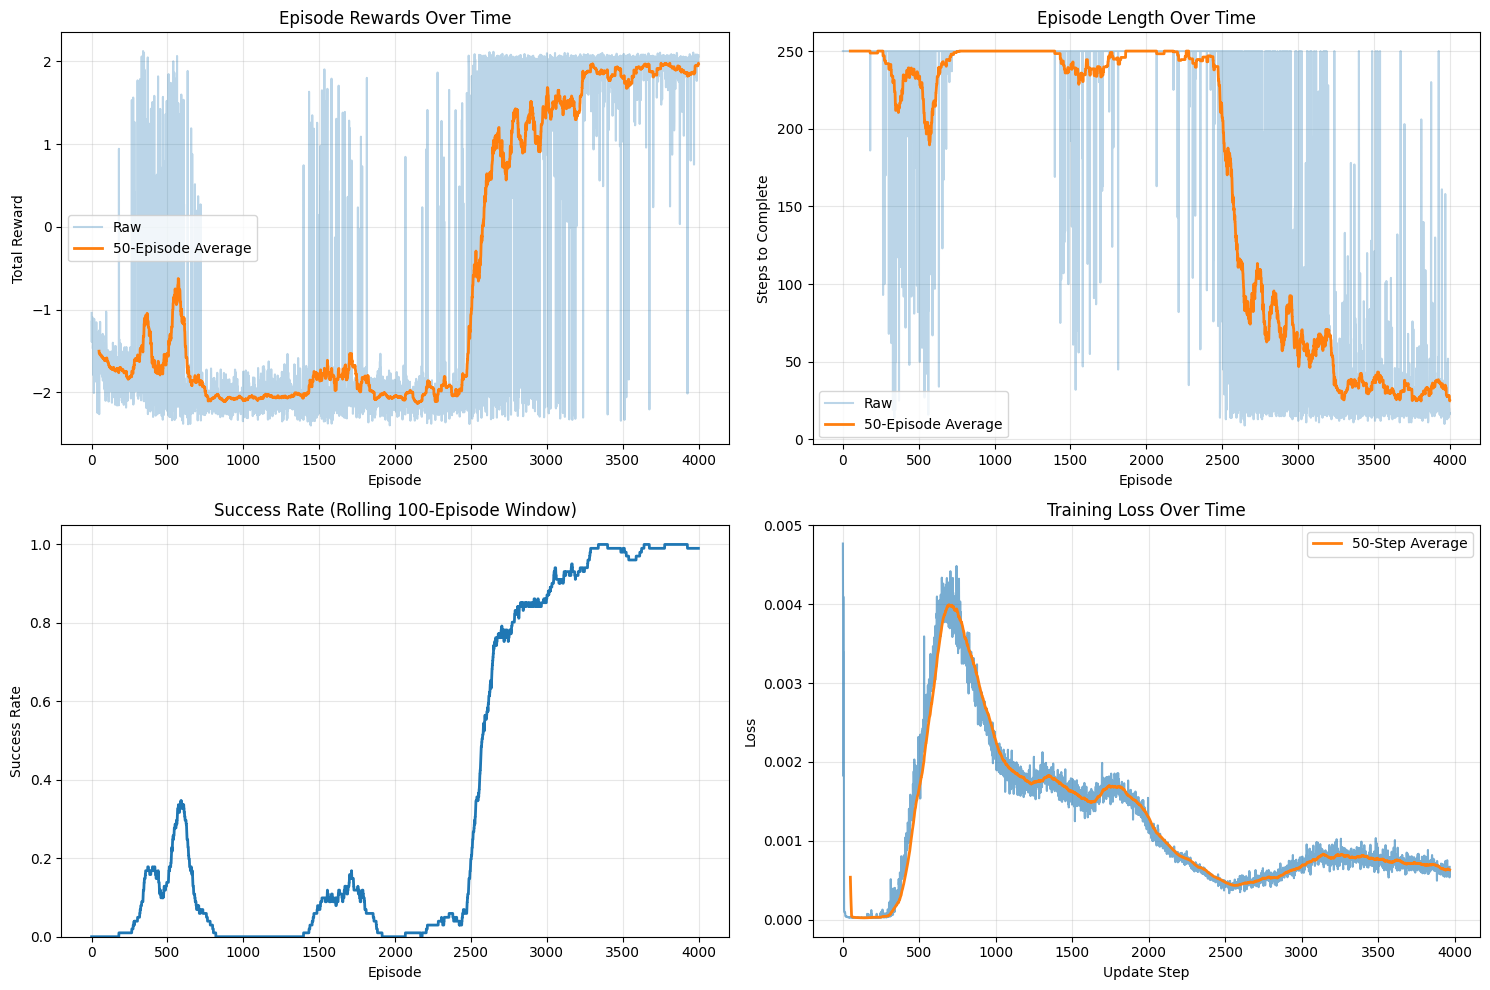


Training Statistics:
  Total episodes: 4000
  Average reward (last 100): 1.91
  Average length (last 100): 30.4
  Success rate (last 100): 99.01%
  Best episode reward: 2.12
  Shortest successful episode: 9 steps


In [8]:
# Cell 8: Visualize Training Results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Episode Rewards
axes[0, 0].plot(episode_rewards, alpha=0.3, label='Raw')
# Moving average
window_size = 50
if len(episode_rewards) >= window_size:
    moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    axes[0, 0].plot(range(window_size-1, len(episode_rewards)), moving_avg, 
                    linewidth=2, label=f'{window_size}-Episode Average')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Episode Rewards Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Episode Lengths
axes[0, 1].plot(episode_lengths, alpha=0.3, label='Raw')
if len(episode_lengths) >= window_size:
    moving_avg_length = np.convolve(episode_lengths, np.ones(window_size)/window_size, mode='valid')
    axes[0, 1].plot(range(window_size-1, len(episode_lengths)), moving_avg_length,
                    linewidth=2, label=f'{window_size}-Episode Average')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps to Complete')
axes[0, 1].set_title('Episode Length Over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Success Rate
success_history = []
window = 100
for i in range(len(episode_rewards)):
    if i < window:
        # Use smaller window at the start
        start_idx = 0
    else:
        start_idx = i - window
    
    successes = sum(1 for j in range(start_idx, i+1) 
                   if j < len(episode_lengths) and episode_lengths[j] < max_steps)
    success_history.append(successes / (i - start_idx + 1))

axes[1, 0].plot(success_history, linewidth=2)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Success Rate')
axes[1, 0].set_title(f'Success Rate (Rolling {window}-Episode Window)')
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Training Loss
if recent_losses:
    axes[1, 1].plot(recent_losses, alpha=0.6)
    if len(recent_losses) >= 50:
        loss_ma = np.convolve(recent_losses, np.ones(50)/50, mode='valid')
        axes[1, 1].plot(range(49, len(recent_losses)), loss_ma, 
                       linewidth=2, label='50-Step Average')
    axes[1, 1].set_xlabel('Update Step')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].set_title('Training Loss Over Time')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('drqn_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTraining Statistics:")
print(f"  Total episodes: {len(episode_rewards)}")
print(f"  Average reward (last 100): {np.mean(episode_rewards[-100:]):.2f}")
print(f"  Average length (last 100): {np.mean(episode_lengths[-100:]):.1f}")
print(f"  Success rate (last 100): {success_history[-1]:.2%}")
print(f"  Best episode reward: {max(episode_rewards):.2f}")
print(f"  Shortest successful episode: {min([l for l in episode_lengths if l < max_steps], default=max_steps)} steps")

In [9]:
torch.save(policy_net.state_dict(), "minigrid_drqn_perfect.pth")